<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/ML_Regression/MiniProject_3_Emotion_Classification_from_Speech_Stan_Ver_8_sachin_visuliazation_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Speech Emotion Classification

## Problem Statement

Build a model to recognize emotion from speech using Ensemble learning

## Learning Objectives

At the end of the mini-project, you will be able to :

* extract the features from audio data
* implement ML classification algorithms individually and as Ensembles, to classify emotions
* record the voice sample and test it with trained model

## Dataset

**TESS Dataset**

The first dataset chosen for this mini-project is the [TESS](https://dataverse.scholarsportal.info/dataset.xhtml?persistentId=doi:10.5683/SP2/E8H2MF) (Toronto emotional speech set) dataset. It contains 2880 files.  A set of 200 target words were spoken in the carrier phrase "Say the word _____' by two actresses and the sets were recorded in seven different emotions (anger, disgust, fear, happiness, pleasant surprise, sadness, and neutral). Both actresses spoke English as their first language, were university educated, and had musical training. Audiometric testing indicated that both actresses had thresholds within the normal range.

**Ravdess Dataset**

The second dataset chosen for this mini-project is [Ravdess](https://zenodo.org/record/1188976#.YLczy4XivIU) (The Ryerson Audio-Visual Database of Emotional Speech and Song). This dataset contains 1440 files: 60 trials per actor x 24 actors = 1440. The RAVDESS contains 24 professional actors (12 female, 12 male), vocalizing two lexically-matched statements in a neutral North American accent. Speech emotions includes calm, happy, sad, angry, fearful, surprise, and disgust expressions. Each expression is produced at two levels of emotional intensity (normal, strong), with an additional neutral expression.

**File naming convention**

Each of the 1440 files has a unique filename. The filename consists of a 7-part numerical identifier (e.g., 03-01-06-01-02-01-12.wav). These identifiers define the stimulus characteristics:

**Filename identifiers**

* Modality (01 = full-AV, 02 = video-only, 03 = audio-only).
* Vocal channel (01 = speech, 02 = song).
* Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
* Emotional intensity (01 = normal, 02 = strong). NOTE: There is no strong intensity for the 'neutral' emotion.
* Statement (01 = "Kids are talking by the door", 02 = "Dogs are sitting by the door").
* Repetition (01 = 1st repetition, 02 = 2nd repetition).
* Actor (01 to 24. Odd numbered actors are male, even numbered actors are female).

Filename example: `03-01-06-01-02-01-12.wav`

    - Audio-only - 03
    - Speech - 01
    - Fearful - 06
    - Normal intensity - 01
    - Statement "dogs" - 02
    - 1st Repetition - 01
    - 12th Actor - 12 Female, as the actor ID number is even.

## Information

**Speech Emotion Recognition (SER)** is the task of recognizing the emotion from  speech, irrespective of the semantics. Humans can efficiently perform this task as a natural part of speech communication, however, the ability to conduct it automatically using programmable devices is a field of active research.

Studies of automatic emotion recognition systems aim to create efficient, real-time methods of detecting the emotions of mobile phone users, call center operators and customers, car drivers, pilots, and many other human-machine communication users. Adding emotions to machines forms an important aspect of making machines appear and act in a human-like manner

Lets gain familiarity with some of the audio based features that are commonly used for SER.

**Mel scale** — The mel scale (derived from the word *melody*) is a perceptual scale of pitches judged by listeners to be equal in distance from one another. The reference point between this scale and normal frequency measurement is defined by assigning a perceptual pitch of 1000 mels to a 1000 Hz tone, 40 dB above the listener's threshold. Above about 500 Hz, increasingly large intervals are judged by listeners to produce equal pitch increments. Refer [here](https://towardsdatascience.com/learning-from-audio-the-mel-scale-mel-spectrograms-and-mel-frequency-cepstral-coefficients-f5752b6324a8) for more detailed information.

**Pitch** — how high or low a sound is. It depends on frequency, higher pitch is high frequency

**Frequency** — speed of vibration of sound, measures wave cycles per second

**Chroma** — Representation for audio where spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma). Computed by summing the log frequency magnitude spectrum across octaves.

**Fourier Transforms** — used to convert from time domain to frequency domain. Time domain shows how signal changes over time. Frequency domain shows how much of the signal lies within each given frequency band over a range of frequencies

**Librosa**

[Librosa](https://librosa.org/doc/latest/index.html) is a Python package, built for speech and audio analytics. It provides modular functions that simplify working with audio data and help in achieving a wide range of applications such as identification of the personal characteristics of different individuals' voice samples, detecting emotions from audio samples etc.

For further details on the Librosa package, refer [here](https://conference.scipy.org/proceedings/scipy2015/pdfs/brian_mcfee.pdf).


### **Kaggle Competition**

Please refer to the link for viewing the
[Kaggle Competition Document](https://drive.google.com/file/d/1kGJfpEC9dayjApciCYZr04NWT7XWkRhV/view?usp=sharing) and join the Kaggle Competition using the hyperlink given in this document under '*Kaggle* Competition site'.


## Grading = 10 Points

In [ ]:
#@title Download the datasets and install packages
!wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Ravdess_Tess.zip
!unzip -qq Ravdess_Tess.zip
# Install packages
!pip -qq install librosa soundfile
!pip -qq install wavio
print("Datasets downloaded successfully!")

replace ravdess/Actor_01/03-01-01-01-01-01-01_neutral.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: Datasets downloaded successfully!


### Import Neccesary Packages

In [ ]:
#Basic packages
import numpy as np
import pandas as pd
import IPython.display as ipd
from matplotlib import pyplot as plt
from datetime import datetime
from IPython.display import Javascript
import IPython.display as ipd
from google.colab import output
from base64 import b64decode
import warnings
warnings.filterwarnings('ignore')

#Audio processing packages
import librosa
import librosa.display
import soundfile
import os, glob, pickle

# sklearn packages
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn import datasets
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn import tree
from sklearn.ensemble import VotingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance

### Work-Flow

* Load the TESS audio data and extract features and labels

* Load the Ravdess audio data and extract features

* Combine both the audio dataset features

* Train and test the model with TESS + Ravdess Data

* Record the team audio samples and add them to TESS + Ravdess data

* Train and test the model with TESS + Ravdess + Team Recorded (combined) data

* Test each of the models with live audio sample recording.

### Load the Tess data and Ravdess data audio files (1 point)

Hint: `glob.glob`

In [ ]:
# YOUR CODE HERE
tess_wav_files = glob.glob("/content/Tess/*/*.wav")
len(tess_wav_files)

2679

In [ ]:
print("Length of the list:",len(tess_wav_files))
type(tess_wav_files)

Length of the list: 2679


list

In [ ]:
print(type(tess_wav_files))
print(tess_wav_files[0])

<class 'list'>
/content/Tess/YAF_neutral/YAF_cheek_neutral.wav


In [ ]:
print(len(tess_wav_files))

2679


STAN-To Do: Number of files (2679) is less than what is specified in the introduction (2880).

#### Play the sample audio

In [ ]:
# YOUR CODE HERE
ipd.Audio("/content/Tess/OAF_Fear/OAF_back_fear.wav")

In [ ]:
ipd.Audio("/content/Tess/OAF_Fear/OAF_back_fear.wav")

In [ ]:
ipd.Audio('/content/Tess/OAF_Fear/OAF_bone_fear.wav')

### Data Exploration and Visualization (1 point)

#### Visualize the distribution of all the labels

In [ ]:
# YOUR CODE HERE
print(tess_wav_files[0])
tess_wav_files[0].split("_")[-1].split(".")[0]
tess_wav_files[1].split("_")[-1].split(".")[0]
tess_wav_files[2].split("_")[-1].split(".")[0]

/content/Tess/YAF_neutral/YAF_cheek_neutral.wav


'neutral'

In [ ]:
emotions_spelling = set()

for file_path in tess_wav_files:
    value_to_add = file_path.split("_")[-1].split(".")[0]
    emotions_spelling.add(value_to_add)
emotions_spelling # Contains all distinct emotion spelling in the file names of TESS

{'angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprised'}

In [ ]:
# YOUR CODE HERE
#Emotion (01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised).
import re
emotions_ = []
mapping = {'angry': '05', 'fear': '06', 'disgust': '07', 'happy': '03', 'sad': '04', 'surprised': '08', 'neutral': '01','calm':'02'}
for file_name in tess_wav_files:
    # print(file_name.split("_")[-1].split(".")[0])
    emotions_.append(mapping[re.sub('[0-9]*', '', file_name.split("_")[-1].split(".")[0])])
set(emotions_)

# Here, encoded values which are same in the Ravdess dataset.

{'01', '03', '04', '05', '06', '07', '08'}

In [ ]:
emotions = {'neutral': '01','calm':'02','happy': '03', 'sad': '04','angry': '05', 'fear': '06', 'disgust': '07',  'surprised': '08' }

STAN-To Do: Is emotion symbols same in both? Is the file name notation same?

STAN-To Do: Distribution of labels to be shown

379 382 379 378 387 391 383


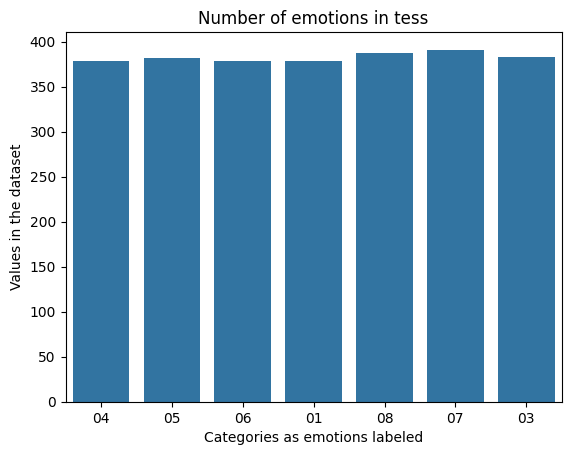

In [ ]:
import re
emotions_ = []
ang = 0
fea = 0
dis = 0
hap = 0
sa = 0
sur = 0
neu = 0
cal = 0

mapping = {'angry': '05', 'fear': '06', 'disgust': '07', 'happy': '03', 'sad': '04', 'surprised': '08', 'neutral': '01','calm':'02'}
for file_name in tess_wav_files:
    # print(file_name.split("_")[-1].split(".")[0])
    mapping_emo = mapping[re.sub('[0-9]*', '', file_name.split("_")[-1].split(".")[0])]

    if mapping_emo == '04':
        sa = sa + 1

    if mapping_emo == '05':
        ang = ang + 1

    if mapping_emo == '06':
        fea = fea + 1

    if mapping_emo == '01':
        neu = neu + 1

    if mapping_emo == '08':
        sur = sur + 1

    if mapping_emo == '07':
        dis = dis + 1

    if mapping_emo == '03':
        hap = hap + 1


print(sa, ang, fea, neu, sur, dis, hap)

# Sample data
categories = ['04', '05', '06', '01', '08', '07', '03']
values = [sa, ang, fea, neu, sur, dis, hap]

import seaborn as sns
# Create bar plot using Seaborn
sns.barplot(x=categories, y=values)

# Add labels and title
plt.xlabel('Categories as emotions labeled')
plt.ylabel('Values in the dataset')
plt.title('Number of emotions in tess')

# Show plot
plt.show()

#### Visualize sample audio signal using librosa

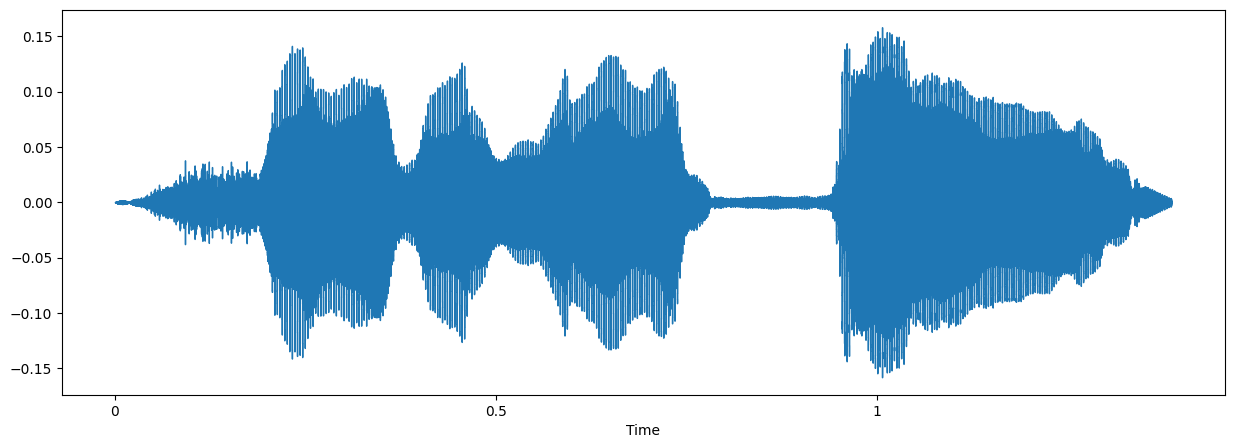

In [ ]:
# YOUR CODE HERE
sample_audio_path = '/content/Tess/OAF_Fear/OAF_bone_fear.wav'

# librosa is used for analyzing and extracting features of an audio signal
data, sampling_rate = librosa.load(sample_audio_path)
plt.figure(figsize=(15, 5))

# librosa.display.waveshow is used to plot waveform of amplitude vs time
librosa.display.waveshow(data, sr=sampling_rate)
plt.show()

### Feature extraction (2 points)

Read one WAV file at a time using `Librosa`. An audio time series in the form of a 1-dimensional array for mono or 2-dimensional array for stereo, along with time sampling rate (which defines the length of the array), where the elements within each of the arrays represent the amplitude of the sound waves is returned by `librosa.load()` function. Refer to the supplementary notebook ('Audio feature extraction')

To know more about Librosa, explore the [link](https://librosa.org/doc/latest/feature.html)

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE
def extract_feature(file_name):
    # load audio
    X, sample_rate = librosa.load(file_name)

    # apply stft()
    stft=np.abs(librosa.stft(X)) #STFT converts signal such that we can know the amplitude of given frequency at a given time
    # print("STFT - ",stft)

    # compute mfcc
    result=np.array([])
    mfccs=np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T,axis=0)
    #Mel-Frequency Cepstral Coefficients (MFCC) used to extract a feature of an audio signal. The MFCC coefs concisely describe the overall shape of a
    #spectral envelope

    # combine the features
    result=np.hstack((result, mfccs)) #1

    # compute chroma features and combine
    chroma=np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T,axis=0)
    #Chroma features are a powerful tool for analyzing audio whose pitches can be meaningfully categorized, often into 12.
    #One main property of Chroma features is that they capture harmonic and melodic characteristics of music, while being robust to changes in timbre
    #and instrumentation
    result=np.hstack((result, chroma)) #2

    # compute melspectrogram and combine
    mel=np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T,axis=0)
    # Is a a spectrogram where the frequencies are converted to the Mel scale. Mel scale is a scale of pitches judged by listeners to be equal in
    #distance one from another
    result=np.hstack((result, mel)) #3
    return result

In [ ]:
sample_tess_feature = extract_feature(tess_wav_files[0]) #,mfcc=True, chroma=True, mel=True)
sample_tess_feature.shape # 180 features coming from mfccs,chroma & mel

(180,)

In [ ]:
sample_tess_feature[:4]

array([-432.94714355,   35.35123062,   -1.08413374,   41.09016418])

In [ ]:
sample_tess_feature

array([-4.32947144e+02,  3.53512306e+01, -1.08413374e+00,  4.10901642e+01,
        8.77839327e-01, -6.34927034e+00,  1.52699637e+00, -1.35768948e+01,
       -2.33966637e+00,  4.46132326e+00, -1.20928621e+01,  1.51307917e+01,
       -4.75752306e+00,  8.87674332e+00,  4.25043201e+00, -4.42290688e+00,
        4.90115213e+00,  9.76360261e-01, -8.07015419e+00,  4.24098253e+00,
       -4.64030552e+00, -2.11298847e+00, -5.45610094e+00, -1.20102990e+00,
       -4.97722292e+00, -1.17129755e+00, -3.66511631e+00, -2.02977920e+00,
       -6.45933819e+00, -2.78950381e+00, -9.59078217e+00,  7.17872238e+00,
        9.18203449e+00,  2.57823830e+01,  2.70400467e+01,  2.49396229e+01,
        1.33664932e+01,  2.52556968e+00, -3.56510401e+00,  1.31599844e+00,
        4.53412086e-01,  5.41323125e-01,  6.80365264e-01,  4.46866721e-01,
        3.81109744e-01,  4.02081281e-01,  5.85760593e-01,  8.19120467e-01,
        5.30216336e-01,  3.94431710e-01,  3.96191001e-01,  4.71731603e-01,
        1.09303789e-02,  

In [ ]:
type(sample_tess_feature)

numpy.ndarray

#### Create a dictionary or a function to encode the emotions

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE HERE
mapping = {'angry': 5, 'fear': 6, 'disgust': 7, 'happy': 3, 'sad': 4, 'surprised': 8, 'neutral': 1,'calm':2}

#### TESS data feature extraction

In [ ]:
# YOUR CODE HERE

In [ ]:
# YOUR CODE
# Declare list to append features and labels
features_tess, labels_tess = [], []

for wv_file in tess_wav_files:
  features_tess.append(extract_feature(wv_file))
  # extracting label
  emt = re.sub('[0-9]*', '', wv_file.split("_")[-1].split(".")[0])  #split("_")[-1].split(".")[0]
  labels_tess.append(mapping[emt])

KeyboardInterrupt: 

In [ ]:
labels_tess[:3]

In [ ]:
print(type(features_tess),len(features_tess),type(labels_tess),len(labels_tess))

In [ ]:
features_array_tess = np.array(features_tess)
labels_array_tess = np.array(labels_tess)

In [ ]:
print(type(features_array_tess),len(features_array_tess),type(labels_array_tess),len(labels_array_tess))

In [ ]:
features_array_tess

In [ ]:
arr = np.array(features_tess[:1]) #[array([-5.50432861e+02,  7.23349609e+01,  2.04760647e+01,  1.08050385e+01 ......])]
print(len(arr[0]))

#### Ravdess data feature extraction

In [ ]:
# YOUR CODE HERE
ravdess_wav_files = glob.glob("/content/ravdess/*/*.wav")
len(ravdess_wav_files)

In [ ]:
print(ravdess_wav_files[0])
ravdess_wav_files[0].split("_")[-1].split(".")[0]

In [ ]:
mapping = {'neutral': '01','calm':'02','happy': '03', 'sad': '04','angry': '05', 'fear': '06', 'disgust': '07',  'surprised': '08' }

In [ ]:
# Declare list to append features and labels
features_ravdess, labels_ravdess = [], []

for wv_file in ravdess_wav_files:
  features_ravdess.append(extract_feature(wv_file))
  # extracting label
  emt = re.sub('[0-9]*', '', wv_file.split("_")[-1].split(".")[0])  #split("_")[-1].split(".")[0]
  labels_ravdess.append(mapping[emt])

In [ ]:
print(type(features_ravdess),len(features_ravdess),type(labels_ravdess),len(labels_ravdess))

In [ ]:
features_array_ravdess = np.array(features_ravdess)
labels_array_ravdess = np.array(labels_ravdess)

In [ ]:
print(type(features_array_ravdess),len(features_array_ravdess),type(labels_array_ravdess),len(labels_array_ravdess))

In [ ]:
labels_array_tess.shape, labels_array_ravdess.shape

#### Save the features

It is best advised to save the features in dataframe and maintain so that feature extraction step is not required to be performed every time.

* Make a DataFrame with features and labels

* Write dataframe into `.CSV` file and save it offline.

In [ ]:
features_array_tess

In [ ]:
labels_array_tess

In [ ]:
new_labels_array_ravdess = [int(x) for x in labels_array_ravdess]

In [ ]:
final_features_array = np.vstack((features_array_tess, features_array_ravdess))
final_labels_array = np.concatenate((labels_array_tess, new_labels_array_ravdess))
# final_features_array = features_array_tess
# final_labels_array = labels_array_tess

In [ ]:
final_features_array

In [ ]:
final_labels_array

In [ ]:
final_features_array.shape, final_labels_array.shape

In [ ]:
features_labels_df = pd.DataFrame(final_features_array)
features_labels_df['labels'] = final_labels_array

In [ ]:
features_labels_df.head()

,0,1,2,3,4,5,6,7,8,9,...,171,172,173,174,175,176,177,178,179,labels
0,-432.947144,35.351231,-1.084134,41.090164,0.877839,-6.349270,1.526996,-13.576895,-2.339666,4.461323,...,0.001208,0.002072,0.003382,0.003873,0.000842,0.000448,0.000583,0.000417,0.000041,1
1,-376.351471,79.262375,-0.853743,26.828857,10.835934,-12.408066,-5.387892,-26.638418,3.876736,0.551862,...,0.006495,0.005553,0.005625,0.002942,0.001399,0.002171,0.002521,0.002059,0.000166,1
2,-394.193054,62.943336,-4.023699,26.673716,-2.321662,-5.699714,-2.249783,-15.899712,3.071914,2.999405,...,0.001997,0.001975,0.002237,0.002167,0.000850,0.001489,0.001632,0.000865,0.000058,1
3,-406.711639,62.672665,-0.319751,16.878714,-2.510805,-0.588051,-2.203720,-9.422874,-4.783314,9.440592,...,0.003787,0.004972,0.005394,0.002915,0.001014,0.001089,0.001434,0.001471,0.000130,1
4,-394.862366,78.454460,-7.795907,17.515102,-9.182662,-7.083034,2.581655,-13.614641,-8.586881,4.672827,...,0.001253,0.001498,0.001356,0.000662,0.000430,0.000476,0.000494,0.000379,0.000028,1


In [ ]:
features_labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3847 entries, 0 to 3846
Columns: 181 entries, 0 to labels
dtypes: float64(180), int64(1)
memory usage: 5.3 MB


In [ ]:
features_labels_df.to_csv("features_labels_df.csv")

In [ ]:
features_labels_df_from_csv = pd.read_csv("features_labels_df.csv")
# X_from_csv = tess_ravdess_df_from_csv['final_features']
# y_from_csv = tess_ravdess_df_from_csv['final_labels']

In [ ]:
features_labels_df_from_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3847 entries, 0 to 3846
Columns: 182 entries, Unnamed: 0 to labels
dtypes: float64(180), int64(2)
memory usage: 5.3 MB


In [ ]:
features_labels_df_from_csv.drop(['Unnamed: 0'], axis=1, inplace=True)

#### Split the data into train and test

In [ ]:
# YOUR CODE HERE
y = features_labels_df_from_csv['labels']
X = features_labels_df_from_csv.drop(['labels'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.30, random_state= 123)

In [ ]:
type(X)

pandas.core.frame.DataFrame

In [ ]:
type(X_train)

pandas.core.frame.DataFrame

In [ ]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,170,171,172,173,174,175,176,177,178,179
2434,-525.127258,63.149776,24.714857,16.995264,16.347637,10.380022,-16.277351,-10.411594,-7.051492,5.507073,...,9.815632e-05,3.802186e-05,2.599559e-05,3.203450e-05,2.771416e-05,2.504794e-05,3.795479e-05,2.940340e-05,1.127903e-05,1.206755e-06
1748,-365.815460,44.217579,-15.175607,-4.311199,-24.620863,3.446152,-1.032605,-9.088100,-11.578182,5.012519,...,3.647152e-03,3.820732e-03,5.529288e-03,7.033417e-03,7.316195e-03,2.667735e-03,1.603890e-03,2.291710e-03,1.716626e-03,1.636883e-04
839,-447.906189,74.321793,16.273159,-4.304433,6.364488,1.794958,-17.916693,0.910615,-18.925110,-5.909132,...,3.495272e-04,3.044413e-04,2.916392e-04,2.683815e-04,2.363154e-04,3.163107e-04,3.861002e-04,3.074644e-04,1.606683e-04,1.246158e-05
1462,-392.246216,56.270042,29.559902,43.481831,1.667145,3.180357,2.530952,-9.447951,-0.744949,-5.679958,...,9.340532e-03,1.199429e-02,1.611979e-02,1.439260e-02,1.161460e-02,7.514395e-03,7.507806e-03,9.238525e-03,5.068015e-03,4.432009e-04
200,-411.144287,54.728668,5.464955,0.969232,4.912270,3.191802,-21.503893,-5.576488,-15.271775,-7.006763,...,8.970199e-04,7.681498e-04,5.668902e-04,4.658467e-04,3.257034e-04,3.358572e-04,3.519724e-04,2.366522e-04,1.064302e-04,5.645418e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1122,-492.913361,53.476593,16.454445,11.544498,18.648914,10.083812,-7.026643,5.679892,-17.439642,-0.626771,...,1.151734e-03,7.631637e-04,6.208499e-04,6.715314e-04,5.165843e-04,3.173606e-04,2.515174e-04,1.659034e-04,6.429107e-05,4.797617e-06
1346,-487.783752,66.914284,33.566654,30.141733,6.260756,11.146859,-0.535193,-6.823961,2.228968,-1.998392,...,2.631206e-03,3.122548e-03,4.478668e-03,3.001850e-03,1.978117e-03,1.240916e-03,1.621571e-03,1.506666e-03,7.851030e-04,7.483034e-05
3454,-509.826263,47.763008,-28.615173,22.230803,-28.934071,9.568296,-21.404312,-1.329534,-5.723031,-3.138276,...,3.398366e-14,1.218177e-14,5.643961e-15,3.699083e-15,2.092237e-15,1.390136e-15,1.053049e-15,2.998987e-15,3.468829e-15,2.155022e-15
3437,-680.487122,71.694901,0.553057,24.584042,0.157189,13.576278,-5.333485,1.363233,-4.647257,-1.633549,...,1.027131e-12,9.401828e-13,8.778395e-13,8.335319e-13,8.004274e-13,7.758364e-13,7.583115e-13,7.457743e-13,7.378146e-13,7.325221e-13


### Train the model with TESS + Ravdess data (2 points)

* Apply different ML algorithms (eg. DecisionTree, RandomForest, etc.) and find the model with best performance

In [ ]:
# YOUR CODE HERE

# Instantiate LogisticRegression, KNN, SVC
log_clf = LogisticRegression()
knn_clf = KNN()
svm_clf = SVC(probability= True)
classifiers = [('lr', log_clf), ('knn', knn_clf), ('svc', svm_clf)]



In [ ]:
simple_log_reg = LogisticRegression()
simple_log_reg.fit(X_train, y_train)
y_pred = simple_log_reg.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"F1 Score for Simple Logistic Regression: {f1}")

F1 Score for Simple Logistic Regression: 0.7521907304385967


In [ ]:
len(X_train)

2692

### Logistic Regression

In [ ]:
#Stan Ver 3: Included grid search for hyper parameter tuning, scaled features
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.preprocessing import StandardScaler

# Preprocess the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=10000)

# Define a grid of parameters to search over
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

# Use F1 score as the metric for optimization with a focus on the macro average for multi-class classification
f1_scorer = make_scorer(f1_score, average='macro')

# Perform grid search with cross-validation
grid_search = GridSearchCV(model, param_grid, scoring=f1_scorer, cv=5)
grid_search.fit(X_train, y_train)

# Evaluate the best model found by grid search
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')


print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Macro F1 Score: {f1}")


Best Parameters: {'C': 0.1, 'penalty': 'l2'}
Best Macro F1 Score: 0.8038874174370424


In [ ]:
f1 = f1_score(y_test, y_pred, average='micro')
print(f"Best Micro F1 Score: {f1}")

Best Micro F1 Score: 0.7506493506493507


In [ ]:
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Best Weighted F1 Score: {f1}")

Best Weighted F1 Score: 0.7506655457073155


### Basic Decision Tree

In [ ]:
basic_dt = DecisionTreeClassifier(random_state=42)
basic_dt.fit(X_train_scaled, y_train)
y_pred = basic_dt.predict(X_test_scaled)
print(f"Model Name={basic_dt.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred)}")
print(f"Precision ={precision_score(y_test, y_pred, average='macro')}, Recall={recall_score(y_test, y_pred, average='macro')},\
                                            F1 Score={f1_score(y_test, y_pred, average='macro')}")

Model Name=DecisionTreeClassifier, Accuracy = 0.7445887445887446
Precision =0.748507983386031, Recall=0.7471182687749341,                                            F1 Score=0.7474565635732751


In [ ]:
tree = basic_dt.tree_
tree

In [ ]:
tree.max_depth, tree.n_leaves, tree.node_count

(21, 305, 609)

### Grid Search for Decision Tree

In [ ]:
"""
from sklearn.model_selection import GridSearchCV

params = {
    'max_leaf_nodes': list(range(2, 10)),
    'max_depth': list(range(1, 4)),
    'min_samples_split': [2, 3, 4]
}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              params,
                              cv=3)

grid_search_cv.fit(X_train, y_train)
y_pred = grid_search_cv.predict(X_test)
print(f"Model Name={grid_search_cv.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred)}")
print(f"Precision ={precision_score(y_test, y_pred, average='macro')}, Recall={recall_score(y_test, y_pred, average='macro')},\
                                            F1 Score={f1_score(y_test, y_pred, average='macro')}")
"""

'\nfrom sklearn.model_selection import GridSearchCV\n\nparams = {\n    \'max_leaf_nodes\': list(range(2, 10)),\n    \'max_depth\': list(range(1, 4)),\n    \'min_samples_split\': [2, 3, 4]\n}\ngrid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),\n                              params,\n                              cv=3)\n\ngrid_search_cv.fit(X_train, y_train)\ny_pred = grid_search_cv.predict(X_test)\nprint(f"Model Name={grid_search_cv.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred)}")\nprint(f"Precision ={precision_score(y_test, y_pred, average=\'macro\')}, Recall={recall_score(y_test, y_pred, average=\'macro\')},                                            F1 Score={f1_score(y_test, y_pred, average=\'macro\')}")\n'

### Bagging Ensemble of Decision Trees (without scaling)

In [ ]:
dt = DecisionTreeClassifier()
bag_clf = BaggingClassifier( base_estimator=dt,     # base estimator to fit on random subsets of the dataset
                            n_estimators=300,       # number of base estimators in the ensemble
                            max_samples=100,        # number of samples to draw from X to train each base estimator.
                                                    # If int, then draw max_samples samples.
                                                    # If float, then draw (max_samples * X.shape[0]) samples.
                            bootstrap=True,         # whether samples are drawn with replacement
                            random_state= 123       # seed used by the random number generator to ensure reproducibility
                            )
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)
print(f"Model Name={bag_clf.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred)}")
print(f"Precision ={precision_score(y_test, y_pred, average='macro')}, Recall={recall_score(y_test, y_pred, average='macro')},\
                                            F1 Score={f1_score(y_test, y_pred, average='macro')}")

Model Name=BaggingClassifier, Accuracy = 0.7740259740259741
Precision =0.800495616357113, Recall=0.7746788861480043,                                            F1 Score=0.7810890928252218


### Bagging Ensemble of Decision Trees (with scaling)

In [ ]:
#Stan Ver 3: Scaled features
#Stan Ver 4: Changed max_samples to 2500 from 100 (F1 went from 0.79 to 0.853 !!! Takes 2 minutes to execute)

dt = DecisionTreeClassifier(random_state=42)
bag_clf = BaggingClassifier( base_estimator=dt,     # base estimator to fit on random subsets of the dataset
                            n_estimators=300,       # number of base estimators in the ensemble
                            max_samples=2500,        # number of samples to draw from X to train each base estimator.
                                                    # If int, then draw max_samples samples.
                                                    # If float, then draw (max_samples * X.shape[0]) samples.
                            bootstrap=True,         # whether samples are drawn with replacement
                            random_state= 123       # seed used by the random number generator to ensure reproducibility
                            )
bag_clf.fit(X_train_scaled, y_train)
y_pred = bag_clf.predict(X_test_scaled)
print(f"Model Name={bag_clf.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred)}")
print(f"Precision ={precision_score(y_test, y_pred, average='macro')}, Recall={recall_score(y_test, y_pred, average='macro')},\
                                            F1 Score={f1_score(y_test, y_pred, average='macro')}")

Model Name=BaggingClassifier, Accuracy = 0.8294372294372294
Precision =0.839912888595497, Recall=0.8306245398495078,                                            F1 Score=0.8330720562584462


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Define the parameter grid
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

param_distributions1 = {
    'n_estimators': [5000],
    'max_depth': [20],
}


# Initialize the classifier
rf_clf_gs = RandomForestClassifier()

# Initialize RandomizedSearchCV
rs = RandomizedSearchCV(rf_clf_gs, param_distributions1, n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV
rs.fit(X_train, y_train)

# Best parameters and score
print(rs.best_params_)
print(rs.best_score_)

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Sample class labels running from 1 to 8
class_labels = [1, 2, 3, 4, 5, 6, 7, 8]

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit label encoder and transform class labels
converted_labels = label_encoder.fit_transform(class_labels)

print("Original class labels:", class_labels)
print("Converted class labels:", converted_labels)

Original class labels: [1, 2, 3, 4, 5, 6, 7, 8]
Converted class labels: [0 1 2 3 4 5 6 7]


In [ ]:
import xgboost as xgb

# Convert the data into DMatrix format

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)




# Set XGBoost parameters
params = {
    'objective': 'binary:hinge',  # Use softmax for multi-class classification
    'num_class': 7,  # Number of classes in the dataset
    'max_depth': 20,  # Maximum depth of each tree
    'eta': 0.3,  # Learning rate
    'eval_metric': 'logloss'  # Evaluation metric
}
params00 = {
    'objective': 'multi:softmax',  # Use softmax for multi-class classification
    'num_class': 8,  # Number of classes in the dataset
    'max_depth': 20,  # Maximum depth of each tree
    'eta': 0.3,  # Learning rate
    'eval_metric': 'logloss'  # Evaluation metric
}





     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 MB 7.6 MB/s eta 0:00:00


In [ ]:
!pip install catboost
import catboost as cb
# Initialize CatBoost classifier
clf = cb.CatBoostClassifier(iterations=200, learning_rate=0.2, depth=8, loss_function='MultiClass')

# Fit the classifier to the training data
clf.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=10)

# Make predictions on the testing set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

param_grid = {
    'learning_rate': [ 0.1],
    'depth': [ 8],
    'l2_leaf_reg': [ 5]
}

# Initialize CatBoost classifier
clf1 = cb.CatBoostClassifier(iterations=100, loss_function='MultiClass')

# Perform grid search
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=3, scoring='accuracy')
grid_search.fit(X, y)
# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

NameError: name 'X_train' is not defined

NameError: name 'cb' is not defined

In [ ]:
f1 = f1_score(y_test, y_pred, average='macro')
print("F1 Score:", f1)

F1 Score: 0.8577032568878888


In [ ]:

# Train the XGBoost model
num_rounds = 10

model_xgb = xgb.train(params, dtrain, 10)

# Make predictions on the testing set
y_pred = model_xgb.predict(dtest)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



XGBoostError: [05:45:51] /workspace/src/objective/hinge.cu:33: Check failed: preds.Size() == info.labels.Size() (18844 vs. 2692) : labels are not correctly providedpreds.size=18844, label.size=2692
Stack trace:
  [bt] (0) /usr/local/lib/python3.10/dist-packages/xgboost/lib/libxgboost.so(+0x1ba24e) [0x7c9e8f5dc24e]
  [bt] (1) /usr/local/lib/python3.10/dist-packages/xgboost/lib/libxgboost.so(+0xa133d1) [0x7c9e8fe353d1]
  [bt] (2) /usr/local/lib/python3.10/dist-packages/xgboost/lib/libxgboost.so(+0x490492) [0x7c9e8f8b2492]
  [bt] (3) /usr/local/lib/python3.10/dist-packages/xgboost/lib/libxgboost.so(+0x4c5488) [0x7c9e8f8e7488]
  [bt] (4) /usr/local/lib/python3.10/dist-packages/xgboost/lib/libxgboost.so(XGBoosterUpdateOneIter+0x70) [0x7c9e8f583ef0]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7c9f15b62e2e]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7c9f15b5f493]
  [bt] (7) /usr/lib/python3.10/lib-dynload/_ctypes.cpython-310-x86_64-linux-gnu.so(+0xa3e9) [0x7c9f15b88

In [ ]:
import xgboost as xgb
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the data into DMatrix format
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Set XGBoost parameters
params = {
    'objective': 'multi:softmax',  # Use softmax for multi-class classification
    'num_class': 3,  # Number of classes in the dataset
    'max_depth': 3,  # Maximum depth of each tree
    'eta': 0.3,  # Learning rate
    'eval_metric': 'merror'  # Evaluation metric
}

# Train the XGBoost model
num_rounds = 10
model = xgb.train(params, dtrain, num_rounds)

# Make predictions on the testing set
y_pred = model.predict(dtest)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


In [ ]:
# STAN Ver 4: max_leaf_nodes changed from *** to None, F1 Score moved from 0.79 to 0.87
rf_clf = RandomForestClassifier(n_estimators=300,           # number of trees in the forest
                                max_leaf_nodes=None,          # grow trees with max_leaf_nodes, selected by
                                                            # relative reduction in impurity.
                                                            # If None, then unlimited number of leaf nodes
                                random_state= 123
                                )
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
#print(rf_clf.__class__.__name__, accuracy_score(y_test, y_pred_rf))
print(f"Model Name={rf_clf.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred_rf)}")
print(f"Precision ={precision_score(y_test, y_pred_rf, average='macro')}, Recall={recall_score(y_test, y_pred_rf, average='macro')},\
                                            F1 Score={f1_score(y_test, y_pred_rf, average='macro')}")

Model Name=RandomForestClassifier, Accuracy = 0.8588744588744589
Precision =0.8671749313404298, Recall=0.8596153438247693,                                            F1 Score=0.8613856484604411


In [ ]:
X_train.shape

(2692, 68)

### Random Forest with Feature Prioritization

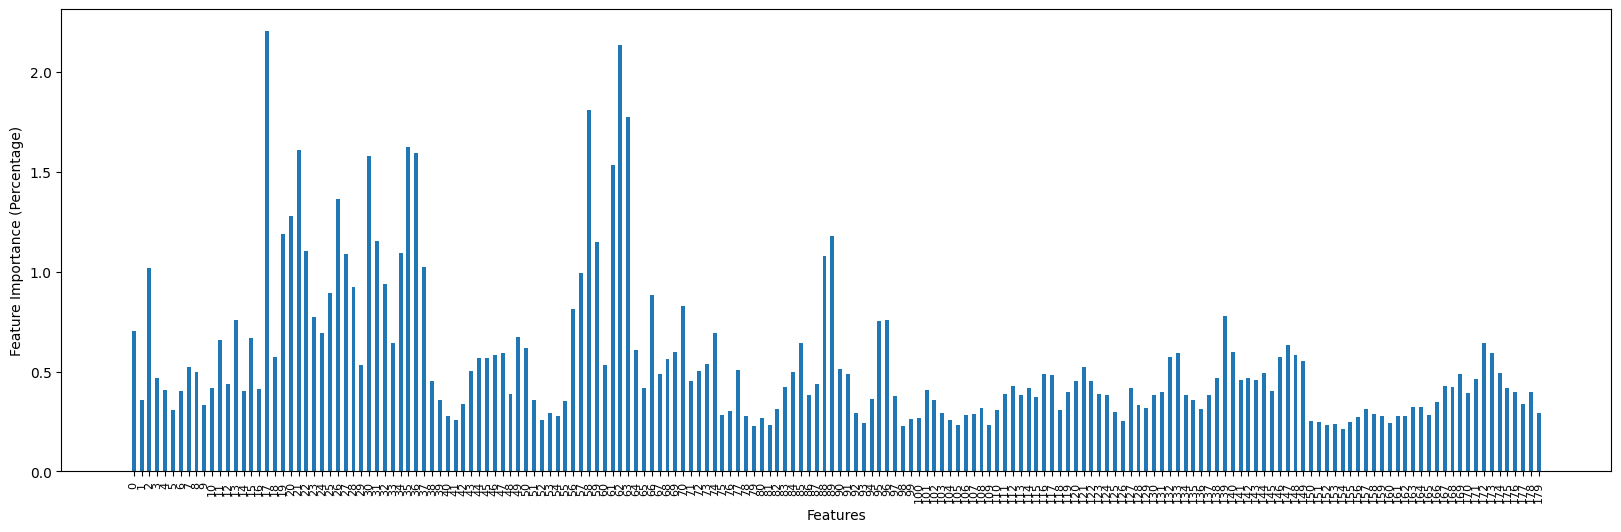

In [ ]:
# STAN Ver 4: Feature Importance Analysis
plt.figure(figsize=(20, 6))
plt.bar(features_labels_df_from_csv.columns[:-1], rf_clf.feature_importances_ * 100,  width =0.5)
plt.xticks(rotation=90, fontsize = 8)
plt.xlabel('Features')
plt.ylabel("Feature Importance (Percentage)", size = 10)
plt.show()

In [ ]:
"""
# Considering features with importance > 0.005
df = features_labels_df_from_csv
colms = df.columns[:-1][rf_clf.feature_importances_> 0.005]
colms
#print(df.columns[:-1])

# Split dataset into training and testing set, considering selected features only
X1 = df[colms].values
y1 = df['labels'].values
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size = 0.3, stratify= y1, random_state= 123)

# Random Forest classifier
rf_ = RandomForestClassifier(n_estimators=400, max_leaf_nodes=None, random_state=123)
rf_.fit(X_train, y_train)
test_acc = accuracy_score(y_test, rf_.predict(X_test))
print("Testing accuracy: ", test_acc)
print(f"F1 Score={f1_score(y_test, rf_.predict(X_test), average='macro')}")
"""

Testing accuracy:  0.8658008658008658
F1 Score=0.8674560386554157


### XGBoost

In [ ]:
from xgboost import XGBClassifier
# Create XGBClassifier object
XGB_clf = XGBClassifier(learning_rate = 0.1)

In [ ]:
"""
XGB_clf.fit(X_train, y_train,
            eval_set = [(X_train, y_train), (X_test, y_test)],
            verbose = False)
"""

In [ ]:
# XGB_clf.fit(X_train, y_train)
            # eval_set = [(X_test, y_test)],
            # verbose = False)

#### Apply the voting classifier

In [ ]:
voting_clf = VotingClassifier(estimators= classifiers, voting='soft')

for clf in (log_clf, knn_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))
    print(f"Model Name={clf.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred)}")
    print(f"Precision ={precision_score(y_test, y_pred, average='macro')}, Recall={recall_score(y_test, y_pred, average='macro')},\
                                            F1 Score={f1_score(y_test, y_pred, average='macro')}")

LogisticRegression 0.7506493506493507
Model Name=LogisticRegression, Accuracy = 0.7506493506493507
Precision =0.7572881871397684, Recall=0.7519783310938297,                                            F1 Score=0.7521907304385967
KNeighborsClassifier 0.8025974025974026
Model Name=KNeighborsClassifier, Accuracy = 0.8025974025974026
Precision =0.806781101266738, Recall=0.8066835789409171,                                            F1 Score=0.8038296051104394
SVC 0.6649350649350649
Model Name=SVC, Accuracy = 0.6649350649350649
Precision =0.75726781444764, Recall=0.6659377622412735,                                            F1 Score=0.6671462122170281
VotingClassifier 0.8043290043290043
Model Name=VotingClassifier, Accuracy = 0.8043290043290043
Precision =0.8192803428833757, Recall=0.8057805369414411,                                            F1 Score=0.8087193372630235


In [ ]:
#Stan Ver 3: Bringing in Best Logistic Regression model based on CV and GridSearch
voting_clf = VotingClassifier(estimators= classifiers, voting='soft')

for clf in (log_clf, knn_clf, svm_clf, voting_clf):
    if clf.__class__.__name__ == "LogisticRegression":
        y_pred = best_model.predict(X_test_scaled)
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))
    print(f"Model Name={clf.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred)}")
    print(f"Precision ={precision_score(y_test, y_pred, average='macro')}, Recall={recall_score(y_test, y_pred, average='macro')},\
                                            F1 Score={f1_score(y_test, y_pred, average='macro')}")

LogisticRegression 0.2701298701298701
Model Name=LogisticRegression, Accuracy = 0.2701298701298701
Precision =0.49890945267760856, Recall=0.2573917621120185,                                            F1 Score=0.2166054233881365
KNeighborsClassifier 0.8025974025974026
Model Name=KNeighborsClassifier, Accuracy = 0.8025974025974026
Precision =0.806781101266738, Recall=0.8066835789409171,                                            F1 Score=0.8038296051104394
SVC 0.6649350649350649
Model Name=SVC, Accuracy = 0.6649350649350649
Precision =0.75726781444764, Recall=0.6659377622412735,                                            F1 Score=0.6671462122170281
VotingClassifier 0.8043290043290043
Model Name=VotingClassifier, Accuracy = 0.8043290043290043
Precision =0.818998249455262, Recall=0.8058005470465442,                                            F1 Score=0.8087732805609393


In [ ]:
#Stan Ver 4: Bringing in Best Logistic Regression model based on CV and GridSearch + Bagging Classifier + RF
#Stan Ver 4: Removing KNN and SVM

voting_clf = VotingClassifier(estimators= classifiers, voting='soft')

for clf in (log_clf, rf_clf, bag_clf, voting_clf):
    if clf.__class__.__name__ == "LogisticRegression":
        y_pred = best_model.predict(X_test_scaled)
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))
    print(f"Model Name={clf.__class__.__name__}, Accuracy = {accuracy_score(y_test, y_pred)}")
    print(f"Precision ={precision_score(y_test, y_pred, average='macro')}, Recall={recall_score(y_test, y_pred, average='macro')},\
                                            F1 Score={f1_score(y_test, y_pred, average='macro')}")

LogisticRegression 0.2701298701298701
Model Name=LogisticRegression, Accuracy = 0.2701298701298701
Precision =0.49890945267760856, Recall=0.2573917621120185,                                            F1 Score=0.2166054233881365
RandomForestClassifier 0.8588744588744589
Model Name=RandomForestClassifier, Accuracy = 0.8588744588744589
Precision =0.8671749313404298, Recall=0.8596153438247693,                                            F1 Score=0.8613856484604411
BaggingClassifier 0.8277056277056277
Model Name=BaggingClassifier, Accuracy = 0.8277056277056277
Precision =0.8384638372042253, Recall=0.8289047983856885,                                            F1 Score=0.8313809846449944
VotingClassifier 0.8043290043290043
Model Name=VotingClassifier, Accuracy = 0.8043290043290043
Precision =0.818998249455262, Recall=0.8058005470465442,                                            F1 Score=0.8087732805609393


## Kaggle Test Set

In [ ]:
kaggle_testset = glob.glob("/content/*.wav") #/content/1.wav

In [ ]:
print(type(kaggle_testset))
print(kaggle_testset[0])
print(len(kaggle_testset))

<class 'list'>
/content/97.wav
201


In [ ]:
kaggle_testset

['/content/97.wav',
 '/content/79.wav',
 '/content/168.wav',
 '/content/76.wav',
 '/content/114.wav',
 '/content/180.wav',
 '/content/158.wav',
 '/content/177.wav',
 '/content/191.wav',
 '/content/96.wav',
 '/content/152.wav',
 '/content/49.wav',
 '/content/98.wav',
 '/content/66.wav',
 '/content/30.wav',
 '/content/176.wav',
 '/content/169.wav',
 '/content/101.wav',
 '/content/31.wav',
 '/content/47.wav',
 '/content/50.wav',
 '/content/77.wav',
 '/content/37.wav',
 '/content/21.wav',
 '/content/188.wav',
 '/content/46.wav',
 '/content/15.wav',
 '/content/11.wav',
 '/content/173.wav',
 '/content/182.wav',
 '/content/86.wav',
 '/content/57.wav',
 '/content/87.wav',
 '/content/147.wav',
 '/content/4.wav',
 '/content/165.wav',
 '/content/185.wav',
 '/content/178.wav',
 '/content/100.wav',
 '/content/5.wav',
 '/content/91.wav',
 '/content/187.wav',
 '/content/149.wav',
 '/content/148.wav',
 '/content/162.wav',
 '/content/60.wav',
 '/content/199.wav',
 '/content/117.wav',
 '/content/150.wav

In [ ]:
int(kaggle_testset[0].split("/")[-1].split(".")[0])

97

In [ ]:
sample_kaggle_feature = extract_feature(kaggle_testset[0]) #,mfcc=True, chroma=True, mel=True)
sample_kaggle_feature.shape # 180 features coming from mfccs,chroma & mel

(180,)

In [ ]:
sample_kaggle_feature[:4]

array([-400.54608154,   58.26567841,   -8.72660637,  -14.76880932])

In [ ]:
# Preparing the X Vector as we need to predic the y vector and match with f1-score directly on Kaggle  y submitting the csv -
features_kaggle = {}

for wv_file in kaggle_testset:
  fileNumber = int(wv_file.split("/")[-1].split(".")[0])
  print(fileNumber)
  features_kaggle[fileNumber]=extract_feature(wv_file)
  #features_kaggle.append(extract_feature(wv_file))
  #print(features_kaggle)

97
79
168
76
114
180
158
177
191
96
152
49
98
66
30
176
169
101
31
47
50
77
37
21
188
46
15
11
173
182
86
57
87
147
4
165
185
178
100
5
91
187
149
148
162
60
199
117
150
51
17
146
193
85
48
132
170
29
142
8
184
195
138
111
136
120
107
81
126
137
58
99
171
135
45
38
194
155
52
25
19
18
151
55
166
88
104
2
115
112
32
102
144
183
186
139
181
190
103
145
159
28
140
27
53
167
153
13
121
42
43
161
92
189
116
44
192
179
129
172
26
133
22
16
157
75
141
105
62
23
130
108
198
109
41
64
128
196
36
34
69
9
63
83
3
143
123
124
80
174
93
200
127
40
7
125
89
164
67
118
95
84
24
122
6
61
163
73
14
175
10
160
1
78
110
106
82
70
201
72
90
35
119
156
94
74
134
113
33
56
39
197
54
20
65
68
12
154
131
71
59


In [ ]:
len(features_kaggle)

201

In [ ]:
features_kaggle[1]

array([-3.78576019e+02,  5.90699425e+01, -8.13677120e+00, -1.90202255e+01,
        8.94271433e-01,  1.01381743e+00, -2.20229282e+01,  2.18903661e+00,
       -1.79647388e+01, -2.22808099e+00, -1.08659410e+01,  4.58340073e+00,
       -5.39496422e+00,  5.62398577e+00, -7.02867508e+00,  2.49252409e-01,
       -2.26879382e+00, -3.59692478e+00, -4.79439402e+00, -1.55554647e+01,
       -7.09053612e+00,  3.37995148e+00, -3.38815737e+00,  2.23402023e+01,
        2.72563610e+01,  2.91274891e+01,  2.46704617e+01,  1.61572113e+01,
       -2.57501811e-01,  4.79826975e+00,  4.38598919e+00,  1.18398581e+01,
        6.90926886e+00, -3.67090774e+00,  5.49959600e-01,  4.82366514e+00,
        6.28679419e+00,  4.90987444e+00, -3.94699574e+00, -8.61317575e-01,
        5.33433616e-01,  6.24476373e-01,  4.75772142e-01,  3.24003488e-01,
        3.67274076e-01,  3.48606080e-01,  2.77413100e-01,  3.45854580e-01,
        4.33721870e-01,  3.86418343e-01,  3.50044131e-01,  4.07377869e-01,
        7.04950839e-02,  

In [ ]:
kaggle_final_features_array = []
for i in range(1,len(features_kaggle)+1):
  kaggle_final_features_array.append(features_kaggle[i])


In [ ]:
len(kaggle_final_features_array)

201

In [ ]:
kaggle_final_features_array = pd.DataFrame(kaggle_final_features_array)
kaggle_final_features_array.to_csv("Kaggle_features_labels_df.csv")
kaggle_features_labels_df_from_csv = pd.read_csv("Kaggle_features_labels_df.csv")
kaggle_features_labels_df_from_csv.shape

(201, 181)

In [ ]:
kaggle_features_labels_df_from_csv.tail(2)

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,170,171,172,173,174,175,176,177,178,179
199,199,-343.382172,24.216105,3.648246,10.011128,-27.279238,-6.275179,-2.942523,-21.930206,-5.876602,...,0.019769,0.029709,0.029813,0.036063,0.013107,0.016889,0.022658,0.026804,0.014250,0.001614
200,200,-400.626709,65.542999,25.910130,39.158016,0.294043,1.012447,-4.481625,-13.157145,1.409536,...,0.004173,0.003316,0.004058,0.004552,0.003581,0.001916,0.003247,0.003692,0.001474,0.000168


In [ ]:
kaggle_features_labels_df_from_csv.drop(['Unnamed: 0'], axis=1, inplace=True)

In [ ]:
y_pred_rf = rf_clf.predict(kaggle_features_labels_df_from_csv)

In [ ]:
len(y_pred_rf)

201

In [ ]:
y_pred_rf

array([5, 7, 4, 4, 4, 7, 1, 4, 5, 6, 8, 6, 7, 5, 8, 4, 3, 7, 4, 5, 1, 6,
       4, 6, 7, 3, 6, 8, 4, 8, 7, 6, 8, 4, 3, 4, 7, 5, 6, 7, 4, 7, 6, 5,
       5, 1, 4, 7, 3, 6, 1, 4, 7, 8, 8, 3, 5, 5, 4, 8, 1, 4, 3, 1, 5, 4,
       3, 3, 1, 7, 4, 7, 1, 4, 8, 6, 3, 8, 8, 5, 8, 3, 6, 6, 8, 4, 8, 4,
       6, 3, 4, 5, 4, 7, 4, 7, 5, 4, 8, 7, 5, 7, 1, 1, 7, 4, 7, 5, 4, 1,
       8, 6, 5, 1, 7, 4, 5, 6, 1, 4, 3, 4, 6, 3, 5, 1, 4, 8, 1, 7, 8, 4,
       6, 5, 7, 8, 6, 1, 4, 3, 3, 1, 6, 7, 8, 4, 6, 5, 3, 5, 6, 3, 8, 4,
       8, 3, 1, 8, 6, 5, 5, 5, 1, 1, 6, 3, 5, 8, 6, 5, 4, 3, 3, 3, 4, 5,
       1, 7, 5, 7, 6, 1, 3, 1, 1, 4, 8, 1, 3, 3, 6, 7, 5, 7, 1, 3, 1, 1,
       4, 5, 4])

In [ ]:
kaggle_pred_df = pd.DataFrame(y_pred_rf)
kaggle_pred_df.to_csv("kaggle_pred_df.csv")

In [ ]:
kaggle_pred_df

,0
0,5
1,7
2,4
3,4
4,4
...,...
196,1
197,1
198,4
199,5


In [ ]:
mapping1 = {1:'neutral',2:'calm',3:'happy',4:'sad',5:'angry',6:'fear',7:'disgust',8:'surprised'}

In [ ]:
kaggle_pred_df['emotion'] = kaggle_pred_df[0].map(mapping1)
print(kaggle_pred_df.head(3))

   0  emotion
0  5    angry
1  7  disgust
2  4      sad


In [ ]:
kaggle_pred_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   0        201 non-null    int64 
 1   emotion  201 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.3+ KB


In [ ]:
kaggle_pred_df.rename(columns = {'0':'Id','emotion':'Label'}, inplace = True)
kaggle_pred_df['Id'] = kaggle_pred_df.index+1
kaggle_pred_df.head(3)

,0,Label,Id
0,5,angry,1
1,7,disgust,2
2,4,sad,3


In [ ]:
kaggle_pred_df[['Id','Label']].to_csv("Team12_Submission_11.csv",index = False, sep = ',')

### Train the model with TESS + Ravdess + Team recorded data (4 points)

* Record the audio samples (team data), extract features and combine with TESS + Ravdess data features
  - Record and gather all the team data samples with proper naming convention in separate folder

    **Hint:** Follow the supplementary notebook to record team data

  - Each team member must record 2 samples for each emotion (Use similar sentences as given in TESS data)

* Train the different ML algorithms and find the model with best performance

#### Load the team data

In [ ]:
# YOUR CODE HERE
team12_wav_files = glob.glob("/content/Team12_Recorded_Audio/*.wav")
print(len(team12_wav_files))
print(type(team12_wav_files))
print(team12_wav_files)

15
<class 'list'>
['/content/Team12_Recorded_Audio/03-01-03-01-02-01-01.wav', '/content/Team12_Recorded_Audio/03-01-05-01-03-01-05.wav', '/content/Team12_Recorded_Audio/03-01-07-01-02-01-01.wav', '/content/Team12_Recorded_Audio/03-01-06-01-02-01-01.wav', '/content/Team12_Recorded_Audio/03-01-04-01-02-01-05.wav', '/content/Team12_Recorded_Audio/03-01-07-01-02-01-05.wav', '/content/Team12_Recorded_Audio/03-01-03-01-02-01-05.wav', '/content/Team12_Recorded_Audio/03-01-08-01-02-01-01.wav', '/content/Team12_Recorded_Audio/03-01-01-01-02-01-05.wav', '/content/Team12_Recorded_Audio/03-01-02-01-02-01-01.wav', '/content/Team12_Recorded_Audio/03-01-06-01-02-01-05.wav', '/content/Team12_Recorded_Audio/03-01-01-01-02-01-01.wav', '/content/Team12_Recorded_Audio/03-01-04-01-02-01-01.wav', '/content/Team12_Recorded_Audio/03-01-05-01-02-01-01.wav', '/content/Team12_Recorded_Audio/03-01-08-01-02-01-05.wav']


#### Extracting features of team data and combine with TESS + Ravdess

In [ ]:
# YOUR CODE HERE
correct_file_names = []
for wv_file in team12_wav_files:
  correct_file_name = wv_file.split("/")[3]
  print(correct_file_name)
  correct_file_names.append(correct_file_name)
print(correct_file_names)

03-01-03-01-02-01-01.wav
03-01-05-01-03-01-05.wav
03-01-07-01-02-01-01.wav
03-01-06-01-02-01-01.wav
03-01-04-01-02-01-05.wav
03-01-07-01-02-01-05.wav
03-01-03-01-02-01-05.wav
03-01-08-01-02-01-01.wav
03-01-01-01-02-01-05.wav
03-01-02-01-02-01-01.wav
03-01-06-01-02-01-05.wav
03-01-01-01-02-01-01.wav
03-01-04-01-02-01-01.wav
03-01-05-01-02-01-01.wav
03-01-08-01-02-01-05.wav
['03-01-03-01-02-01-01.wav', '03-01-05-01-03-01-05.wav', '03-01-07-01-02-01-01.wav', '03-01-06-01-02-01-01.wav', '03-01-04-01-02-01-05.wav', '03-01-07-01-02-01-05.wav', '03-01-03-01-02-01-05.wav', '03-01-08-01-02-01-01.wav', '03-01-01-01-02-01-05.wav', '03-01-02-01-02-01-01.wav', '03-01-06-01-02-01-05.wav', '03-01-01-01-02-01-01.wav', '03-01-04-01-02-01-01.wav', '03-01-05-01-02-01-01.wav', '03-01-08-01-02-01-05.wav']


In [ ]:
features_team12, labels_team12 = [], []

for wv_file in correct_file_names:
  full_file_name = "/content/Team12_Recorded_Audio/"+wv_file
  features_team12.append(extract_feature(full_file_name))
  # extracting label
  # print(wv_file)
  emt = int(wv_file.split("-")[2])  #split("_")[-1].split(".")[0]
  # print(emt)
  labels_team12.append(emt)

In [ ]:
features_team12

In [ ]:
features_array_team12 = np.array(features_team12)
labels_array_team12 = np.array(labels_team12)
labels_array_team12 = np.array([int(x) for x in labels_array_team12])

In [ ]:
final_features_array_team = np.vstack((final_features_array, features_array_team12))
final_labels_array_team = np.concatenate((final_labels_array, labels_array_team12))

In [ ]:
print(final_features_array.shape,features_array_team12.shape,final_features_array_team.shape)

(3847, 180) (15, 180) (3862, 180)


In [ ]:
print(final_labels_array.shape,labels_array_team12.shape,final_labels_array_team.shape)

(3847,) (15,) (3862,)


In [ ]:
features_labels_team_df = pd.DataFrame(final_features_array_team)
features_labels_team_df['labels'] = final_labels_array_team

In [ ]:
features_labels_team_df.shape

(3862, 181)

In [ ]:
features_labels_team_df.to_csv("features_labels_team_df.csv")

In [ ]:
features_labels_team_df_from_csv = pd.read_csv("features_labels_team_df.csv")

In [ ]:
features_labels_team_df_from_csv.drop(['Unnamed: 0'], axis=1, inplace=True)

In [ ]:
features_labels_team_df_from_csv.shape

(3862, 181)

#### Train the different ML algorithms

In [ ]:
# YOUR CODE HERE
# YOUR CODE HERE
y_team = features_labels_team_df_from_csv['labels']
X_team = features_labels_team_df_from_csv.drop(['labels'], axis=1)
X_train_team, X_test_team, y_train_team, y_test_team = train_test_split(X_team, y_team, test_size= 0.30, random_state= 123)

In [ ]:
#  Using RF model as it was the best performing
rf_clf_team = RandomForestClassifier(n_estimators=300,           # number of trees in the forest
                                max_leaf_nodes=None,          # grow trees with max_leaf_nodes, selected by
                                                            # relative reduction in impurity.
                                                            # If None, then unlimited number of leaf nodes
                                random_state= 123
                                )
rf_clf_team.fit(X_train_team, y_train_team)
y_pred_rf_team = rf_clf_team.predict(X_test_team)
#print(rf_clf.__class__.__name__, accuracy_score(y_test, y_pred_rf))
print(f"Model Name={rf_clf_team.__class__.__name__}, Accuracy = {accuracy_score(y_test_team, y_pred_rf_team)}")
print(f"Precision ={precision_score(y_test_team, y_pred_rf_team, average='macro')}, Recall={recall_score(y_test_team, y_pred_rf_team, average='macro')},\
                                            F1 Score={f1_score(y_test_team, y_pred_rf_team, average='macro')}")

Model Name=RandomForestClassifier, Accuracy = 0.8628127696289906
Precision =0.8703207736197301, Recall=0.8637599801102518,                                            F1 Score=0.8651652991912229


#### Test the best working model with live audio recording

In [ ]:
# choose the best working model and assign below
MODEL = rf_clf_team

In [ ]:
#emotions = {'neutral': '01','calm':'02','happy': '03', 'sad': '04','angry': '05', 'fear': '06', 'disgust': '07',  'surprised': '08' }
emotions = {'neutral': 1,'calm': 2,'happy': 3, 'sad': 4,'angry': 5, 'fear': 6, 'disgust': 7,  'surprised': 8 }

In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

happy


### Report Analysis

- Report the accuracy for 10 live samples using the model trained on TESS+Ravdess+Team data
- Discuss with the team mentor regarding deep learnt audio features. Read a related article [here](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8805181).


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

disgust


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

sad


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

happy


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

disgust


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

sad


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

surprised


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

surprised


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

surprised


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

surprised


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

surprised


In [ ]:
#@title Speak the utterance and test
from IPython.display import Javascript
from google.colab import output
from base64 import b64decode

RECORD = """
const sleep  = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  recorder = new MediaRecorder(stream)
  chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async ()=>{
    blob = new Blob(chunks)
    text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

if not os.path.exists('ModelTesting/'):
    os.mkdir("ModelTesting/")
def record(sec=3):
    print("Start speaking!")
    now = datetime.now()
    current_time = now.strftime("%Y-%m-%d_%H-%M-%S")
    display(Javascript(RECORD))
    s = output.eval_js('record(%d)' % (sec*1000))
    b = b64decode(s.split(',')[1])
    with open('ModelTesting/audio_'+current_time+'.wav','wb') as f:
        f.write(b)
    return 'ModelTesting/audio_'+current_time+'.wav'
test_i = record()
pred = MODEL.predict(extract_feature(test_i).reshape(1,-1))
idx_emotion = list(emotions.values()).index(pred[0])
print(list(emotions.keys())[idx_emotion])
ipd.Audio(test_i)

Start speaking!


<IPython.core.display.Javascript object>

surprised
